## 이미지 탐지결과를 DataFrame에 저장 후 CSV로 저장한후 이를 읽어 - 요약 통계 처리

In [1]:
!pip install ultralytics opencv-python playsound==1.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00


In [12]:
from torch import avg_pool1d
import os
import pandas as pd
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('yolo11n.pt')
img_dir = 'images'
img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
print(img_paths)

records = []
for path in img_paths:
    results = model(path, conf=0.25, verbose=False)[0] # 단일 이미지 추론
    boxes = results.boxes
    names = results.names
    # print(names)

    if len(boxes) == 0:
      records.append({
        'image':os.path.basename(path),
        'object_count':0,
        'clasess':'',
        "avg_confidence":0.0
      })
      continue

    # cpu() : pytroch명령어, pytorch텐서로 반환된 값을 cpu메모리로 옮겨 numpy배열(기본float)로 변환
    cls_id = boxes.cls.cpu().numpy().astype(int)  # 탐지된 객체들의 class id(정수 라벨 번호)
    print("cls_id :",cls_id) # [0 0 3 0 0 2] 이미지 6개 감지 ...

    confs = boxes.conf.cpu().numpy() # 탐지된 객체들의 신뢰도(확률)
    print("confs :",confs)

    classes = [names[i] for i in cls_id] # 탐지된 객체들의 class 이름
    print(classes)

    avg_confidence = float(confs.mean()) # 신뢰도의 평균값
    print(avg_confidence)

    records.append({
        'image':os.path.basename(path),
        'object_count':len(cls_id),
        'clasess':','.join(sorted(set(classes))),
        "avg_confidence":round(avg_confidence, 3)
      })

['images/image3.png', 'images/image1.jpg', 'images/image2.jpeg']
cls_id : [0 0 3 0 0 2]
confs : [    0.89472     0.88528     0.84669     0.69414     0.28265     0.25905]
['person', 'person', 'motorcycle', 'person', 'person', 'car']
0.6437545418739319
cls_id : [0 0]
confs : [    0.81587     0.46298]
['person', 'person']
0.6394230127334595
cls_id : [ 0  0 26  0]
confs : [    0.82473     0.72216     0.43466     0.30244]
['person', 'person', 'handbag', 'person']
0.57099848985672


In [15]:
# records를 DataFrame에 저장
df = pd.DataFrame(records)
print(df)

df.to_csv('yolo6report.csv', index=False, encoding='utf-8-sig')
print('csv로 저장 성공')

         image  object_count                clasess  avg_confidence
0   image3.png             6  car,motorcycle,person           0.644
1   image1.jpg             2                 person           0.639
2  image2.jpeg             4         handbag,person           0.571
csv로 저장 성공


         image  object_count                clasess  avg_confidence
0   image3.png             6  car,motorcycle,person           0.644
1   image1.jpg             2                 person           0.639
2  image2.jpeg             4         handbag,person           0.571

총 이미지수 : 3
총 탐지 갯수 : 12
전체 평균 신뢰도: 0.618
클래스별 등장 이미지 수 :
    car : 1
    motorcycle : 1
    person : 3
    handbag : 1
       object_count  avg_confidence
count           3.0         3.00000
mean            4.0         0.61800
std             2.0         0.04078
min             2.0         0.57100
25%             3.0         0.60500
50%             4.0         0.63900
75%             5.0         0.64150
max             6.0         0.64400

가장 많이 감지된 객체는 ?
image                        image3.png
object_count                          6
clasess           car,motorcycle,person
avg_confidence                    0.644
Name: 0, dtype: object
------------------------------------------------------------


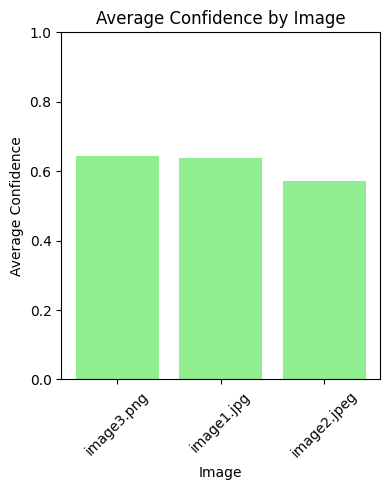

In [42]:
# csv 읽기(loding)
mydf = pd.read_csv("yolo6report.csv")
print(mydf)
print()

num_images = len(mydf)
total_object = mydf['object_count'].sum() # 탐지 객체 총 갯수

# 전체 confidence 평균
overall_avg_conf = mydf.loc[mydf['avg_confidence'] > 0,"avg_confidence"].mean() if total_object > 0 else 0.0
print('총 이미지수 :',num_images)
print('총 탐지 갯수 :', total_object)
print(f'전체 평균 신뢰도: {overall_avg_conf:.3f}')

# 클래스별 등장 빈도
class_counts = {}
for cls_str in mydf['clasess']:
  if cls_str:
    for c in cls_str.split(','):
      class_counts[c] = class_counts.get(c, 0) + 1 # 나눠진 list 하나씩 반복하기 - 카운팅하기

print('클래스별 등장 이미지 수 :')
for k, v in class_counts.items():
  print(f'    {k} : {v}')


print(mydf[['object_count','avg_confidence']].describe())
print()

max_row = mydf.loc[mydf['object_count'].idxmax()]
print('가장 많이 감지된 객체는 ?\n{}'.format(max_row))
print('-'*60)

# 평균 신뢰도 막대그래프
plt.figure(figsize=(4, 5))
plt.bar(mydf['image'], mydf['avg_confidence'], color='lightgreen')
plt.xlabel('Image')
plt.ylabel('Average Confidence')
plt.title('Average Confidence by Image')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()